# Supervised Classification: Churn Prediction
**Goal:** Build and evaluate a supervised classification model to predict customer churn.  
**Algorithms compared:** Logistic Regression vs. Random Forest  
**Dataset:** Synthetic churn dataset (1000 samples, 10 features)


In [1]:
# ── 1. Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)

np.random.seed(42)
print("All libraries loaded ✓")


All libraries loaded ✓


## 1. Data Generation & Preprocessing

In [2]:
# ── 2. Generate Synthetic Churn Dataset ────────────────────────────────────
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=7,
    n_redundant=2, n_classes=2, weights=[0.70, 0.30],
    flip_y=0.03, random_state=42
)

feature_names = [
    'tenure_months', 'monthly_charges', 'total_charges',
    'num_products', 'support_calls', 'contract_type',
    'payment_method', 'has_internet', 'has_streaming', 'satisfaction_score'
]

df = pd.DataFrame(X, columns=feature_names)
df['churn'] = y

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean():.2%}")
df.head()


Dataset shape: (1000, 11)

Class distribution:
churn
0    691
1    309
Name: count, dtype: int64

Churn rate: 30.90%


,tenure_months,monthly_charges,total_charges,num_products,support_calls,contract_type,payment_method,has_internet,has_streaming,satisfaction_score,churn
0,-1.791436,-2.105935,1.796615,-0.849716,-1.237639,0.690362,2.054655,-0.323471,0.183930,1.341055,0
1,0.096930,-1.574040,1.478934,-1.451238,-0.505524,0.415114,-0.460077,0.461823,1.472862,-0.025499,0
2,-1.463581,-0.955144,0.265074,-0.621975,0.505316,1.434901,-0.000723,-1.140210,2.179704,1.414849,0
3,-0.427399,-1.843641,1.278538,-2.155590,-2.351641,-0.506784,2.933718,-1.472570,-0.950161,0.552035,0
4,-4.191126,-1.403401,0.469541,0.463029,2.192326,2.185556,1.089738,-0.252712,3.655343,-2.090761,0


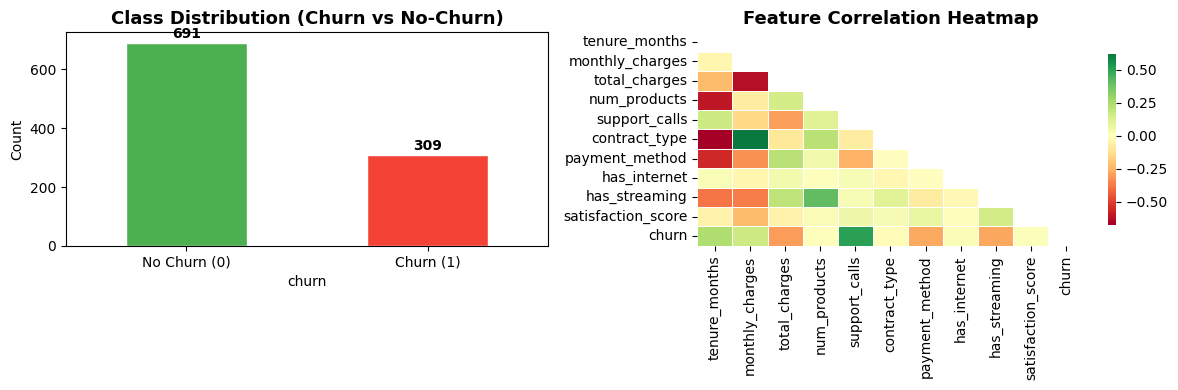

EDA plots saved ✓


In [3]:
# ── 3. Exploratory Data Analysis ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
colors = ['#4CAF50', '#F44336']
df['churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Churn vs No-Churn)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/claude/eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved ✓")


In [4]:
# ── 4. Train / Test Split ───────────────────────────────────────────────────
X_raw = df.drop('churn', axis=1)
y_raw = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain churn rate : {y_train.mean():.2%}")
print(f"Test  churn rate : {y_test.mean():.2%}")


Training set : 800 samples
Test set     : 200 samples

Train churn rate : 30.88%
Test  churn rate : 31.00%


## 2. Model Training with Cross-Validation

In [5]:
# ── 5. Build Pipelines ──────────────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=8,
                                   random_state=42, n_jobs=-1))
])

# ── 6. 5-Fold Stratified Cross-Validation ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {'Logistic Regression': lr_pipeline, 'Random Forest': rf_pipeline}

print("=" * 60)
print(f"{'Model':<25} {'CV Accuracy':>12} {'CV F1':>10} {'CV ROC-AUC':>12}")
print("=" * 60)

cv_results = {}
for name, model in models.items():
    acc  = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    f1   = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    auc  = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {'acc': acc, 'f1': f1, 'auc': auc}
    print(f"{name:<25} {acc.mean():.4f}±{acc.std():.3f}  "
          f"{f1.mean():.4f}±{f1.std():.3f}  {auc.mean():.4f}±{auc.std():.3f}")

print("=" * 60)


Model                      CV Accuracy      CV F1   CV ROC-AUC
Logistic Regression       0.8538±0.008  0.7260±0.026  0.8527±0.034


Random Forest             0.8925±0.020  0.8108±0.038  0.9431±0.008


## 3. Test Set Evaluation & Metrics

In [6]:
# ── 7. Fit on Full Train, Evaluate on Test ──────────────────────────────────
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'y_pred' : y_pred,
        'y_proba': y_proba,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_proba),
    }

# Summary table
metrics_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in res.items()
           if k not in ('y_pred', 'y_proba')}
    for name, res in results.items()
}).T

print("\n=== Test Set Metrics ===")
print(metrics_df.to_string())
metrics_df



=== Test Set Metrics ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression     0.825     0.7872  0.5968  0.6789   0.8292
Random Forest           0.880     0.8800  0.7097  0.7857   0.9165


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.825,0.7872,0.5968,0.6789,0.8292
Random Forest,0.880,0.8800,0.7097,0.7857,0.9165


In [7]:
# ── 8. Classification Reports ────────────────────────────────────────────────
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f" {name}")
    print('='*50)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Churn', 'Churn']))



 Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.93      0.88       138
       Churn       0.79      0.60      0.68        62

    accuracy                           0.82       200
   macro avg       0.81      0.76      0.78       200
weighted avg       0.82      0.82      0.82       200


 Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       138
       Churn       0.88      0.71      0.79        62

    accuracy                           0.88       200
   macro avg       0.88      0.83      0.85       200
weighted avg       0.88      0.88      0.88       200



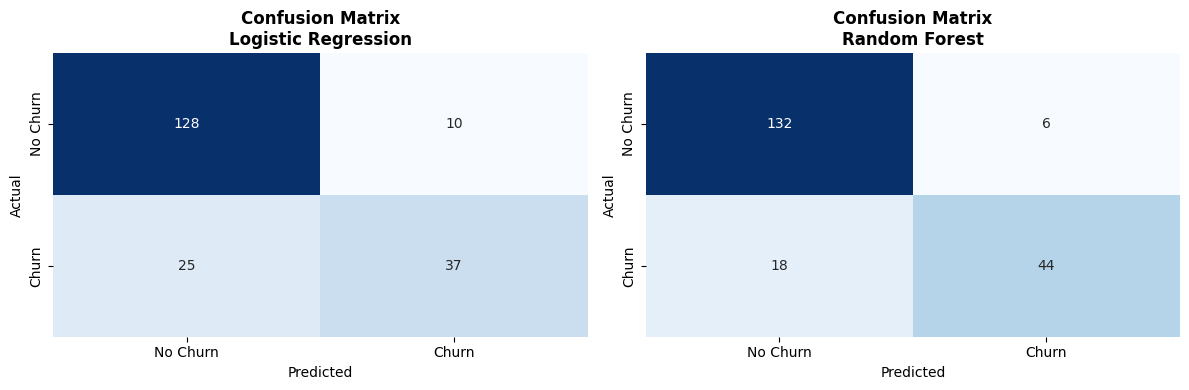

In [8]:
# ── 9. Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/home/claude/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


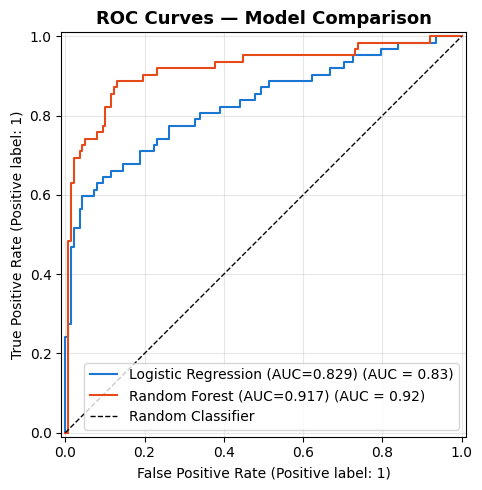

In [9]:
# ── 10. ROC Curves ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ['#1976D2', '#E64A19']

for (name, res), color in zip(results.items(), colors_roc):
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'], name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


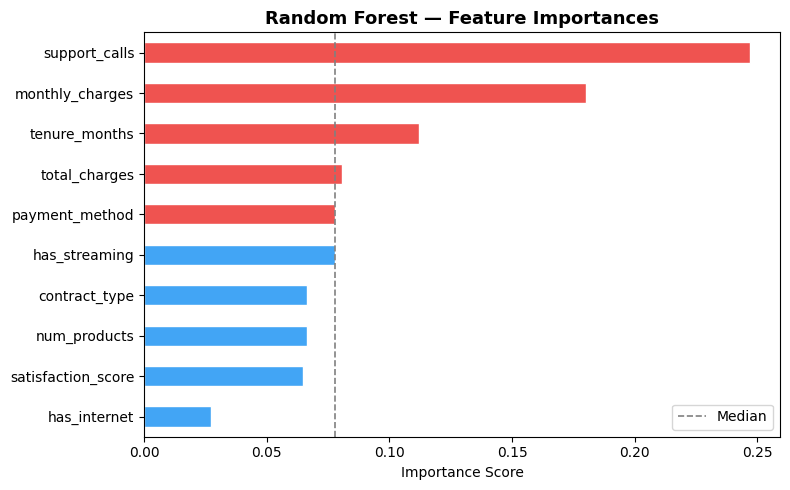

In [10]:
# ── 11. Feature Importance (Random Forest) ──────────────────────────────────
rf_clf = rf_pipeline.named_steps['clf']
importances = pd.Series(rf_clf.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#EF5350' if v > importances.median() else '#42A5F5' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.median(), color='gray', linestyle='--', lw=1.2, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


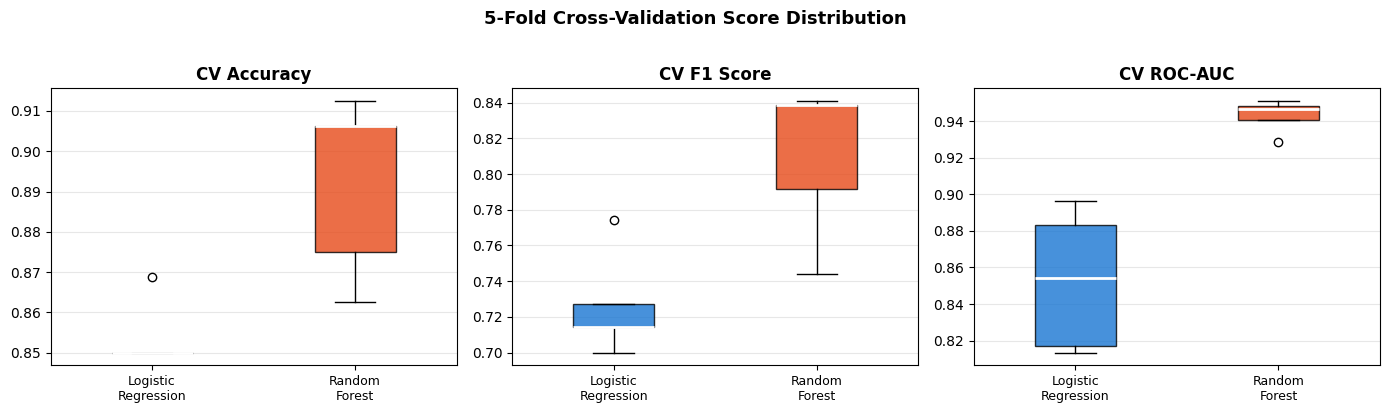


✅ All analysis complete!


In [11]:
# ── 12. Cross-Validation Score Comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metric_labels = {'acc': 'Accuracy', 'f1': 'F1 Score', 'auc': 'ROC-AUC'}
box_colors = ['#1976D2', '#E64A19']

for ax, (metric_key, metric_name) in zip(axes, metric_labels.items()):
    data = [cv_results[m][metric_key] for m in models]
    bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest'], fontsize=9)
    ax.set_title(f'CV {metric_name}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('5-Fold Cross-Validation Score Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All analysis complete!")
